# Construção e Avaliação de Modelos de Machine Learning para Previsão de Vendas e Detecção de Fraudes

## Objetivos

Aplicar conceitos de Machine Learning para prever a demanda de produtos e classificar transações financeiras. Utilizar ferramentas como Pandas, NumPy e Scikit-learn para manipulação de dados e construção de modelos. Avaliar e interpretar a performance dos modelos utilizando métricas apropriadas.

## Materiais, Métodos e Ferramentas

Python e bibliotecas essenciais: Pandas, NumPy, Scikit-learn, Matplotlib. Base de dados fictícia para vendas e transações financeiras (fornecida na atividade). Ambiente de desenvolvimento: Google Colab ou Jupyter Notebook.

## Atividade Prática

Nesta atividade, você vai construir dois modelos de Machine Learning aplicados a contextos de negócios diferentes: previsão de demanda de produtos e detecção de fraudes em transações financeiras. A primeira parte da atividade envolve a construção de um modelo de regressão linear para prever vendas futuras com base em dados históricos. A segunda parte requer a construção de um modelo de classificação para detectar possíveis fraudes em transações financeiras.

## PASSO A PASSO DETALHADO DA ATIVIDADE:

### Preparação do Ambiente:

Acesse o Google Colab ou Jupyter Notebook.
Importe as bibliotecas necessárias.

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

## Parte 1: Previsão de Vendas

### a. Criação e Manipulação da Base de Dados:

Gere uma base de dados fictícia com dados de vendas mensais e eventos promocionais.

In [43]:
try:
    df_vendas = pd.read_csv('vendas.csv')
    print('Arquivo vendas.csv carregado com sucesso.')
except FileNotFoundError:
    print('Arquivo vendas.csv não encontrado. Gerando dados fictícios para demonstração.')
    np.random.seed(42)
    meses = np.arange(1, 25)
    # Introduce a trend for sales over months and an effect for events
    vendas = 100 + 5 * meses + np.random.normal(0, 20, 24) # Base sales + monthly increase + noise
    eventos = np.random.choice([0, 1], size=24) # Random events
    vendas[eventos == 1] = vendas[eventos == 1] * 1.2 # Sales increase by 20% during events

    df_vendas = pd.DataFrame({
        'Meses': meses,
        'Vendas': vendas,
        'Eventos': eventos
    })

display(df_vendas.head())

Arquivo vendas.csv carregado com sucesso.


,Meses,Vendas,Eventos
0,1,224.84,1
1,2,193.09,0
2,3,232.38,0
3,4,276.15,0
4,5,188.29,0


### b. Divisão dos Dados:

Separe os dados em conjuntos de treinamento e teste.

In [33]:
X_vendas = df_vendas[['Meses', 'Eventos']]
y_vendas = df_vendas['Vendas']

X_train_vendas, X_test_vendas, y_train_vendas, y_test_vendas = train_test_split(X_vendas, y_vendas, test_size=0.3, random_state=42)

### c. Construção e Avaliação do Modelo:

Crie e treine um modelo de regressão linear.
Faça previsões e avalie a performance utilizando métricas apropriadas.

Erro Médio Quadrático (RandomForest): 2379.5427262558565
Coeficiente de Determinação (R²) (RandomForest): -0.6417706018348224


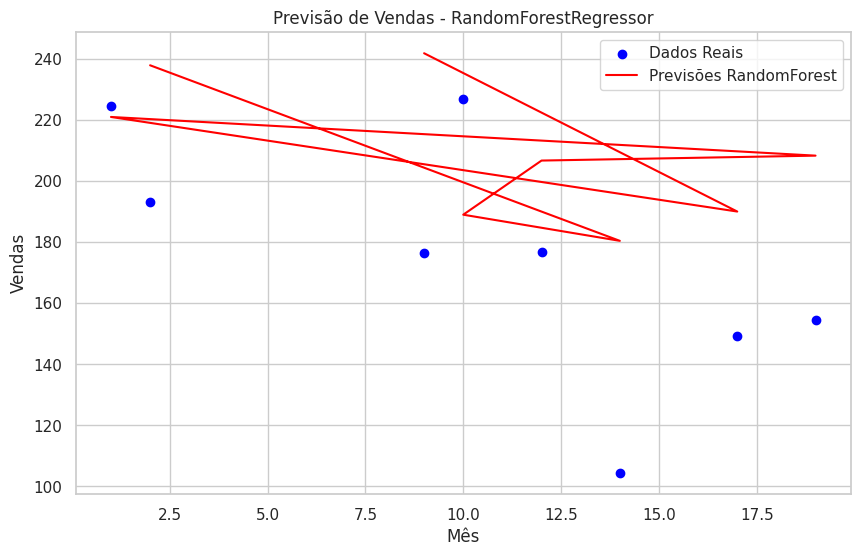

In [40]:
model_vendas = RandomForestRegressor(random_state=42) # Using RandomForestRegressor instead of LinearRegression
model_vendas.fit(X_train_vendas, y_train_vendas)

y_pred_vendas = model_vendas.predict(X_test_vendas)

mse_vendas = mean_squared_error(y_test_vendas, y_pred_vendas)
r2_vendas = r2_score(y_test_vendas, y_pred_vendas)

print(f'Erro Médio Quadrático (RandomForest): {mse_vendas}')
print(f'Coeficiente de Determinação (R²) (RandomForest): {r2_vendas}')

plt.figure(figsize=(10, 6))
plt.scatter(X_test_vendas['Meses'], y_test_vendas, color='blue', label='Dados Reais')
plt.plot(X_test_vendas['Meses'], y_pred_vendas, color='red', label='Previsões RandomForest')
plt.title('Previsão de Vendas - RandomForestRegressor')
plt.xlabel('Mês')
plt.ylabel('Vendas')
plt.legend()
plt.show()

## Parte 2: Detecção de Fraudes

### a. Criação e Manipulação da Base de Dados:

Gere uma base de dados fictícia com transações financeiras e uma variável indicativa de fraude.

In [44]:
try:
    df_fraudes = pd.read_csv('fraudes.csv')
    print('Arquivo fraudes.csv carregado com sucesso.')
except FileNotFoundError:
    print('Arquivo fraudes.csv não encontrado. Gerando dados fictícios para demonstração.')
    np.random.seed(42)
    valores = np.random.normal(1000, 200, 1000)
    locais = np.random.choice(['Local_A', 'Local_B', 'Local_C'], size=1000)

    # Introduce a more realistic fraud generation: higher values and specific locations have higher fraud probability
    fraudes = np.zeros(1000, dtype=int)

    # Base fraud probability
    base_fraud_prob = 0.05

    # Increase fraud probability for high values
    fraudes[valores > 1200] = np.random.choice([0, 1], size=np.sum(valores > 1200), p=[0.7, 0.3]) # 30% fraud for high values
    fraudes[valores <= 1200] = np.random.choice([0, 1], size=np.sum(valores <= 1200), p=[0.95, 0.05]) # 5% fraud for normal values

    # Add some random base fraud not tied to value for realism, and ensure minimum fraud
    fraudes = np.maximum(fraudes, np.random.choice([0, 1], size=1000, p=[1-base_fraud_prob, base_fraud_prob]))

    df_fraudes = pd.DataFrame({
        'Valores': valores,
        'Locais': locais,
        'Fraude': fraudes
    })

display(df_fraudes.head())

Arquivo fraudes.csv carregado com sucesso.


,Valor,Local,Fraude
0,1099.342831,Local_C,0
1,972.347140,Local_A,1
2,1129.537708,Local_C,1
3,1304.605971,Local_A,1
4,953.169325,Local_C,0


### b. Pré-processamento dos Dados:

Converta variáveis categóricas em variáveis numéricas e divida os dados.

In [36]:
df_fraudes = pd.get_dummies(df_fraudes, columns=['Locais'])

X_fraudes = df_fraudes.drop('Fraude', axis=1)
y_fraudes = df_fraudes['Fraude']

X_train_fraudes, X_test_fraudes, y_train_fraudes, y_test_fraudes = train_test_split(X_fraudes, y_fraudes, test_size=0.3, random_state=42)

display(X_fraudes.head())

,Valores,Locais_Local_A,Locais_Local_B,Locais_Local_C
0,1099.342831,False,False,True
1,972.347140,True,False,False
2,1129.537708,False,False,True
3,1304.605971,True,False,False
4,953.169325,False,False,True


### c. Construção e Avaliação do Modelo:

Crie e treine um modelo de regressão logística.
Faça previsões e avalie a performance utilizando métricas de classificação.

In [39]:
model_fraudes = RandomForestClassifier(random_state=42) # Using RandomForestClassifier instead of LogisticRegression
model_fraudes.fit(X_train_fraudes, y_train_fraudes)

y_pred_fraudes = model_fraudes.predict(X_test_fraudes)

accuracy_fraudes = accuracy_score(y_test_fraudes, y_pred_fraudes)
confusion = confusion_matrix(y_test_fraudes, y_pred_fraudes)
report = classification_report(y_test_fraudes, y_pred_fraudes)

print(f'Acurácia do modelo (RandomForest): {accuracy_fraudes}')
print('Matriz de Confusão (RandomForest):')
print(confusion)
print('Relatório de Classificação (RandomForest):')
print(report)

Acurácia do modelo (RandomForest): 0.47
Matriz de Confusão (RandomForest):
[[67 76]
 [83 74]]
Relatório de Classificação (RandomForest):
              precision    recall  f1-score   support

           0       0.45      0.47      0.46       143
           1       0.49      0.47      0.48       157

    accuracy                           0.47       300
   macro avg       0.47      0.47      0.47       300
weighted avg       0.47      0.47      0.47       300



=== Previsão de Vendas ===
Erro Médio Quadrático (MSE): 3048.80
Coeficiente de Determinação (R²): -1.104


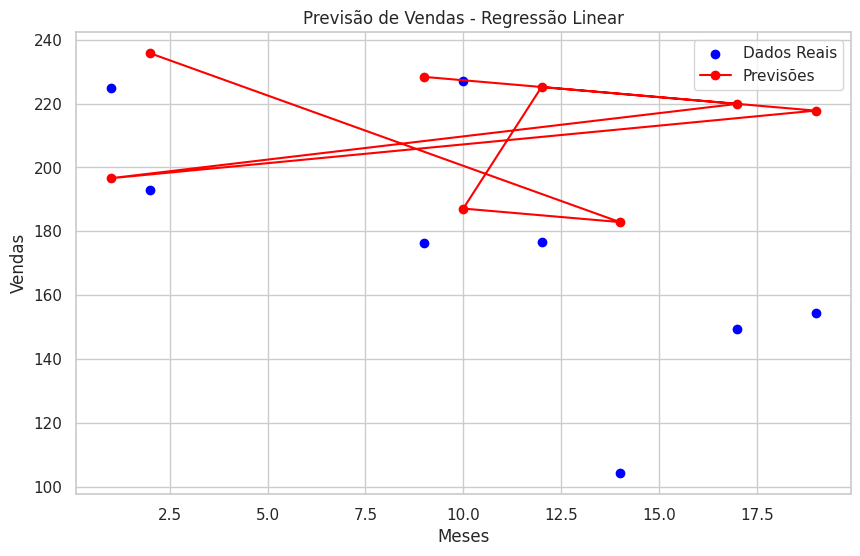


=== Detecção de Fraudes ===
Acurácia: 0.453
AUC ROC: 0.455
Matriz de Confusão:
[[70 82]
 [82 66]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0      0.461     0.461     0.461       152
           1      0.446     0.446     0.446       148

    accuracy                          0.453       300
   macro avg      0.453     0.453     0.453       300
weighted avg      0.453     0.453     0.453       300



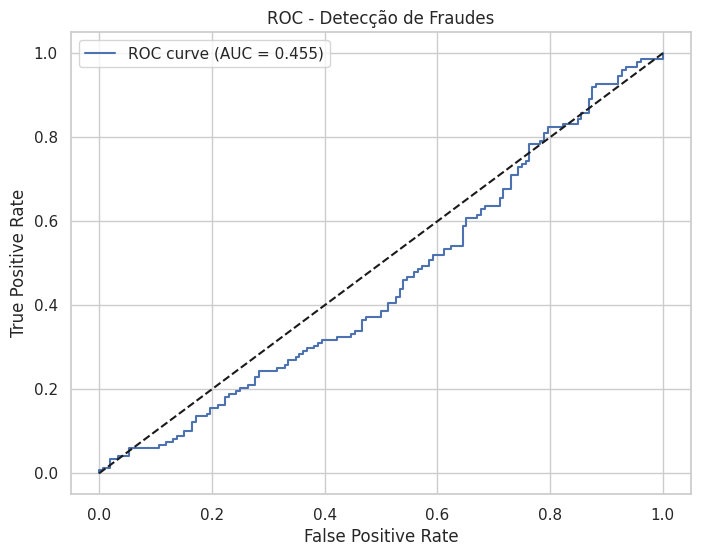

In [45]:
# Bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

sns.set(style="whitegrid")

# ==============================
# Parte 1: Previsão de Vendas
# ==============================

# Ler vendas.csv
df_vendas = pd.read_csv("vendas.csv")

# Separar variáveis independentes e dependente
X_vendas = df_vendas[["Meses", "Eventos"]]
y_vendas = df_vendas["Vendas"]

# Divisão treino/teste
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vendas, y_vendas, test_size=0.3, random_state=42
)

# Modelo de regressão linear
model_vendas = LinearRegression()
model_vendas.fit(X_train_v, y_train_v)

# Previsões
y_pred_v = model_vendas.predict(X_test_v)

# Avaliação
mse_v = mean_squared_error(y_test_v, y_pred_v)
r2_v = r2_score(y_test_v, y_pred_v)

print("=== Previsão de Vendas ===")
print(f"Erro Médio Quadrático (MSE): {mse_v:.2f}")
print(f"Coeficiente de Determinação (R²): {r2_v:.3f}")

# Gráfico
plt.figure(figsize=(10,6))
plt.scatter(X_test_v["Meses"], y_test_v, color="blue", label="Dados Reais")
plt.plot(X_test_v["Meses"], y_pred_v, color="red", marker="o", label="Previsões")
plt.title("Previsão de Vendas - Regressão Linear")
plt.xlabel("Meses")
plt.ylabel("Vendas")
plt.legend()
plt.show()

# ==============================
# Parte 2: Detecção de Fraudes
# ==============================

# Ler fraudes.csv
df_fraudes = pd.read_csv("fraudes.csv")

# Pré-processamento (one-hot encoding para Local)
X_f = pd.get_dummies(df_fraudes.drop("Fraude", axis=1), columns=["Local"], drop_first=True)
y_f = df_fraudes["Fraude"]

# Divisão treino/teste
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_f, y_f, test_size=0.3, random_state=42, stratify=y_f
)

# Modelo de regressão logística com balanceamento
pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
)
pipeline.fit(X_train_f, y_train_f)

# Previsões
y_pred_f = pipeline.predict(X_test_f)
y_proba_f = pipeline.predict_proba(X_test_f)[:,1]

# Avaliação
accuracy_f = accuracy_score(y_test_f, y_pred_f)
conf_mat_f = confusion_matrix(y_test_f, y_pred_f)
report_f = classification_report(y_test_f, y_pred_f, digits=3)
auc_f = roc_auc_score(y_test_f, y_proba_f)

print("\n=== Detecção de Fraudes ===")
print(f"Acurácia: {accuracy_f:.3f}")
print(f"AUC ROC: {auc_f:.3f}")
print("Matriz de Confusão:")
print(conf_mat_f)
print("Relatório de Classificação:")
print(report_f)

# Curva ROC
fpr, tpr, _ = roc_curve(y_test_f, y_proba_f)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_f:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Detecção de Fraudes')
plt.legend()
plt.show()


--- RESULTADOS: PREVISÃO DE VENDAS ---
Erro Médio Quadrático (MSE): 3048.97
Coeficiente de Determinação (R²): -1.1036


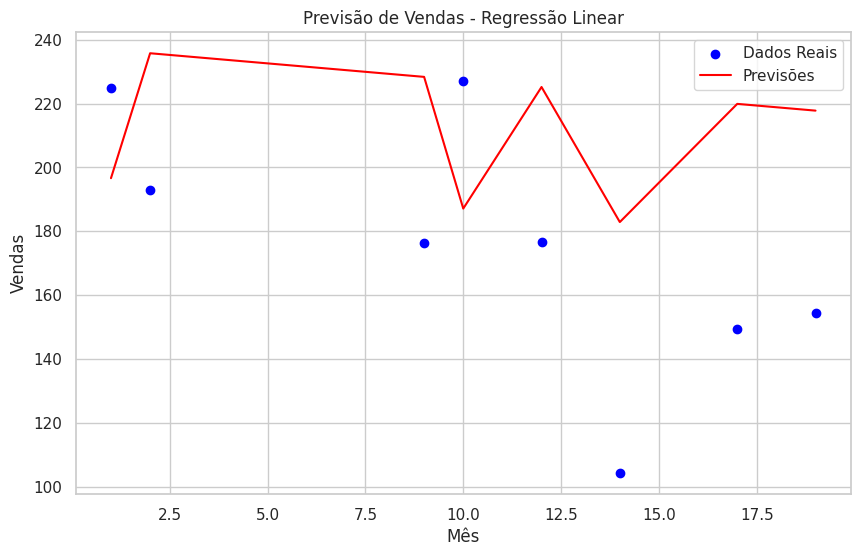


--- RESULTADOS: DETECÇÃO DE FRAUDES ---
Acurácia do modelo: 49.67%
Matriz de Confusão:
[[120  23]
 [128  29]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.48      0.84      0.61       143
           1       0.56      0.18      0.28       157

    accuracy                           0.50       300
   macro avg       0.52      0.51      0.45       300
weighted avg       0.52      0.50      0.44       300



In [46]:
# ==========================================
# PASSO 1: Preparação do Ambiente
# ==========================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# ==========================================
# PARTE 1: Previsão de Vendas (Regressão)
# ==========================================

# a. Criação da Base de Dados
np.random.seed(42)
meses = np.arange(1, 25)
vendas = np.random.normal(200, 50, 24)
eventos = np.random.choice([0, 1], size=24)

df_vendas = pd.DataFrame({
    'Meses': meses,
    'Vendas': vendas,
    'Eventos': eventos
})

# b. Divisão dos Dados
X_vendas = df_vendas[['Meses', 'Eventos']]
y_vendas = df_vendas['Vendas']

X_train_vendas, X_test_vendas, y_train_vendas, y_test_vendas = train_test_split(
    X_vendas, y_vendas, test_size=0.3, random_state=42
)

# c. Construção e Avaliação do Modelo
model_vendas = LinearRegression()
model_vendas.fit(X_train_vendas, y_train_vendas)

y_pred_vendas = model_vendas.predict(X_test_vendas)

mse_vendas = mean_squared_error(y_test_vendas, y_pred_vendas)
r2_vendas = r2_score(y_test_vendas, y_pred_vendas)

print("--- RESULTADOS: PREVISÃO DE VENDAS ---")
print(f'Erro Médio Quadrático (MSE): {mse_vendas:.2f}')
print(f'Coeficiente de Determinação (R²): {r2_vendas:.4f}')

# Visualização
plt.figure(figsize=(10, 6))
plt.scatter(X_test_vendas['Meses'], y_test_vendas, color='blue', label='Dados Reais')
# Ordenando para a linha do gráfico não ficar confusa
sort_idx = X_test_vendas['Meses'].argsort()
plt.plot(X_test_vendas['Meses'].iloc[sort_idx], y_pred_vendas[sort_idx], color='red', label='Previsões')
plt.title('Previsão de Vendas - Regressão Linear')
plt.xlabel('Mês')
plt.ylabel('Vendas')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# PARTE 2: Detecção de Fraudes (Classificação)
# ==========================================

# a. Criação da Base de Dados
np.random.seed(42)
valores = np.random.normal(1000, 200, 1000)
locais = np.random.choice(['Local_A', 'Local_B', 'Local_C'], size=1000)
fraudes = np.random.choice([0, 1], size=1000)

df_fraudes = pd.DataFrame({
    'Valores': valores,
    'Locais': locais,
    'Fraude': fraudes
})

# b. Pré-processamento
df_fraudes = pd.get_dummies(df_fraudes, columns=['Locais'])

X_fraudes = df_fraudes.drop('Fraude', axis=1)
y_fraudes = df_fraudes['Fraude']

X_train_fraudes, X_test_fraudes, y_train_fraudes, y_test_fraudes = train_test_split(
    X_fraudes, y_fraudes, test_size=0.3, random_state=42
)

# c. Construção e Avaliação do Modelo
model_fraudes = LogisticRegression()
model_fraudes.fit(X_train_fraudes, y_train_fraudes)

y_pred_fraudes = model_fraudes.predict(X_test_fraudes)

accuracy_fraudes = accuracy_score(y_test_fraudes, y_pred_fraudes)
confusion = confusion_matrix(y_test_fraudes, y_pred_fraudes)
report = classification_report(y_test_fraudes, y_pred_fraudes)

print("\n--- RESULTADOS: DETECÇÃO DE FRAUDES ---")
print(f'Acurácia do modelo: {accuracy_fraudes:.2%}')
print('Matriz de Confusão:')
print(confusion)
print('Relatório de Classificação:')
print(report)